# Gamow peak for the reaction $^7\mathrm{Be}+p$

This notebook estimates the position of the Gamow peak, $E_0$, for the solar reaction

$$
{}^7\mathrm{Be}+p
$$

The goal is to find the energy at which the product of the Maxwell-Boltzmann factor and the quantum tunneling factor is maximal.


## 1. Physical idea

For two charged nuclei in stellar plasma, the reaction-rate integrand contains approximately

$$
\exp\left[-\frac{E}{kT}-\sqrt{\frac{E_G}{E}}\right].
$$

The first term suppresses large energies because particles in the Maxwell-Boltzmann tail are rare. The second term suppresses small energies because tunneling through the Coulomb barrier becomes very unlikely.

Their product has a maximum. This maximum is called the **Gamow peak**, and its position is denoted by $E_0$.


## 2. Parameters for $^7\mathrm{Be}+p$

For the reaction

$$
{}^7\mathrm{Be}+p,
$$

the charges are

$$
Z_{{}^7\mathrm{Be}}=4,\qquad Z_p=1.
$$

Therefore,

$$
Z_aZ_b=4.
$$

The reduced mass is

$$
\mu=\frac{m_a m_b}{m_a+m_b}.
$$

Using approximate nuclear masses,

$$
m_{{}^7\mathrm{Be}}\approx 7u,\qquad m_p\approx 1u,
$$

we get

$$
\mu=\frac{7\cdot 1}{7+1}u=\frac{7}{8}u=0.875u.
$$

Here $u$ is the atomic mass unit. In nuclear physics,

$$
1u\,c^2\approx 931.5\ \mathrm{MeV}.
$$


In [3]:
# Basic parameters

Z_Be7 = 4
Z_p = 1
Z_product = Z_Be7 * Z_p

mu_u = 7 * 1 / (7 + 1)  # reduced mass in atomic mass units
u_c2_MeV = 931.5        # 1 u c^2 in MeV

mu_c2_MeV = mu_u * u_c2_MeV

print(f"Z_a Z_b = {Z_product}")
print(f"Reduced mass mu = {mu_u:.3f} u")
print(f"mu c^2 = {mu_c2_MeV:.1f} MeV")


Z_a Z_b = 4
Reduced mass mu = 0.875 u
mu c^2 = 815.1 MeV


## 3. Gamow energy

In convenient astrophysical units,

$$
E_G = 978\,\mu(Z_aZ_b)^2\ \mathrm{keV},
$$

where $\mu$ is measured in atomic mass units $u$.

For $^7\mathrm{Be}+p$:

$$
E_G = 978\cdot 0.875\cdot 4^2\ \mathrm{keV}.
$$


In [4]:
# Gamow energy in keV

E_G_keV = 978 * mu_u * Z_product**2

print(f"Gamow energy E_G = {E_G_keV:.1f} keV")
print(f"Gamow energy E_G = {E_G_keV/1000:.2f} MeV")


Gamow energy E_G = 13692.0 keV
Gamow energy E_G = 13.69 MeV


## 4. Position of the Gamow peak

The reaction-rate integrand is approximately

$$
G(E)=\exp[-f(E)],
$$

where

$$
f(E)=\frac{E}{kT}+\sqrt{\frac{E_G}{E}}.
$$

Since the exponential function is monotonic, the maximum of $G(E)$ corresponds to the minimum of $f(E)$.

The condition is

$$
f'(E_0)=0.
$$

This gives

$$
E_0=
\left[
\frac{E_G(kT)^2}{4}
\right]^{1/3}.
$$

For the solar core we take

$$
kT\simeq 1.30\ \mathrm{keV}.
$$


In [5]:
# Solar-core thermal energy

kT_keV = 1.30

# Gamow peak position
E0_keV = (E_G_keV * kT_keV**2 / 4)**(1/3)

print(f"kT = {kT_keV:.2f} keV")
print(f"E0 = {E0_keV:.2f} keV")


kT = 1.30 keV
E0 = 17.95 keV


## 5. Optional: width of the Gamow window

If one wants to estimate the width of the Gamow window, one can expand $f(E)$ near $E_0$:

$$
f(E)\approx f(E_0)+\frac12 f''(E_0)(E-E_0)^2.
$$

This gives a Gaussian approximation to the peak. A common estimate of the width is

$$
\Delta E\approx 4\sqrt{\frac{E_0 kT}{3}}.
$$

Then the Gamow window is roughly

$$
E_0-\frac{\Delta E}{2}
\lesssim E \lesssim
E_0+\frac{\Delta E}{2}.
$$

This step is optional if the task asks only for $E_0$.


In [6]:
# Optional Gamow-window width

Delta_E_keV = 4 * (E0_keV * kT_keV / 3)**0.5

E_left_keV = E0_keV - Delta_E_keV / 2
E_right_keV = E0_keV + Delta_E_keV / 2

print(f"Delta E = {Delta_E_keV:.2f} keV")
print(f"Gamow window ≈ {E_left_keV:.2f} - {E_right_keV:.2f} keV")


Delta E = 11.16 keV
Gamow window ≈ 12.37 - 23.53 keV


## 6. Plot of the normalized Gamow peak

Below we plot

$$
G(E)=\exp\left[-\frac{E}{kT}-\sqrt{\frac{E_G}{E}}\right]
$$

and normalize it to its maximum value.


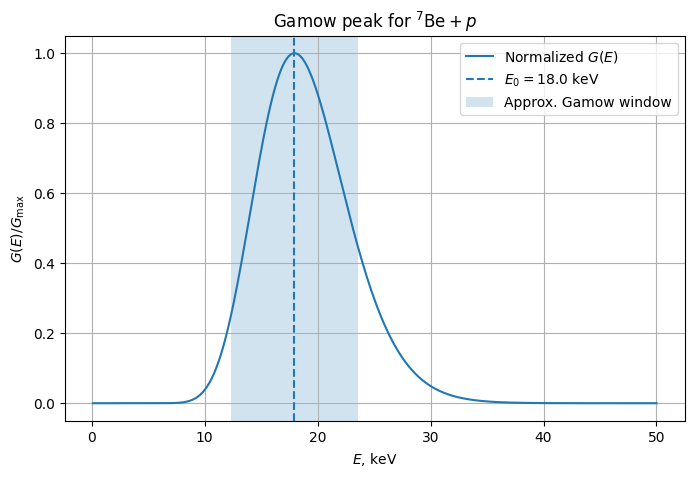

In [7]:
import numpy as np
import matplotlib.pyplot as plt

E = np.linspace(0.1, 50, 1000)  # keV

G = np.exp(-E / kT_keV - np.sqrt(E_G_keV / E))
G_norm = G / np.max(G)

plt.figure(figsize=(8, 5))
plt.plot(E, G_norm, label=r"Normalized $G(E)$")
plt.axvline(E0_keV, linestyle="--", label=fr"$E_0={E0_keV:.1f}$ keV")
plt.axvspan(E_left_keV, E_right_keV, alpha=0.2, label="Approx. Gamow window")

plt.xlabel(r"$E$, keV")
plt.ylabel(r"$G(E)/G_{\max}$")
plt.title(r"Gamow peak for $^7\mathrm{Be}+p$")
plt.legend()
plt.grid(True)
plt.show()


## 7. Final result

For the reaction

$$
{}^7\mathrm{Be}+p\rightarrow{}^8\mathrm{B}+\gamma,
$$

using

$$
Z_aZ_b=4,\qquad \mu\simeq 0.875u,\qquad kT\simeq 1.30\ \mathrm{keV},
$$

we obtain

$$
E_G\simeq 13.7\ \mathrm{MeV},
$$

and

$$
\boxed{E_0\simeq 18\ \mathrm{keV}.}
$$

Thus, the main contribution to this reaction in the solar core comes from particles with energies much larger than the typical thermal energy $kT\simeq 1.3\ \mathrm{keV}$. This is why both the Maxwell-Boltzmann tail and quantum tunneling are essential.
